In [9]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/asl_project/data', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 03 - Training and Evaluation

This notebook trains the ASL fingerspelling classifier used by the Znak Streamlit app.
It is designed to rerun end-to-end from a clean runtime.

The workflow is:

1. Load `data/landmarks_merged.csv`
2. Clean invalid rows and verify class/source counts
3. Normalize landmarks using the same pipeline as the app
4. Split into stratified train/test sets
5. Apply augmentation only to the training set
6. Tune six model families with cross-validation
7. Compare test performance using accuracy, precision, recall, and F1-score
8. Export report-ready plots and save the deployment model


## 1. Setup

The notebook works from either the local repository or a Colab folder. If you run it locally, start Jupyter from the project root or from the `notebooks/` folder. If you run it in Colab, make sure the project folder exists at `/content/drive/MyDrive/asl_project` or update `PROJECT_ROOT` manually.

`SAVE_DEPLOYMENT_ARTIFACTS = True` writes the final model into `app/best_model.pkl` and `app/label_encoder.pkl`.

In [10]:
from pathlib import Path
import json
import os
import tempfile
import pickle
import time
import warnings

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'matplotlib'))
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')

import numpy as np
import pandas as pd
import sklearn

from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception as exc:
    LIGHTGBM_AVAILABLE = False
    LGBMClassifier = None
    print(f'LightGBM is unavailable and will be skipped: {exc}')

if LIGHTGBM_AVAILABLE:
    sklearn_major_minor = tuple(int(part) for part in sklearn.__version__.split('.')[:2])
    if sklearn_major_minor >= (1, 8):
        LIGHTGBM_AVAILABLE = False
        print(
            'LightGBM is installed, but this environment uses sklearn '
            f'{sklearn.__version__}. This LightGBM/sklearn combination is incompatible, '
            'so LightGBM will be skipped. Use sklearn < 1.8 or a newer compatible LightGBM to include it.'
        )

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE = 0.20
SAVE_DEPLOYMENT_ARTIFACTS = True
N_JOBS = -1

def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / 'data' / 'landmarks_merged.csv').exists():
            return candidate

    colab_candidate = Path('/content/drive/MyDrive/asl_project')
    if (colab_candidate / 'data' / 'landmarks_merged.csv').exists():
        return colab_candidate

    raise FileNotFoundError(
        'Could not find data/landmarks_merged.csv. Run from the repo root, '
        'or set PROJECT_ROOT manually.'
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / 'data' / 'landmarks_merged.csv'
APP_DIR = PROJECT_ROOT / 'app'
FIGURE_DIR = PROJECT_ROOT / 'report_figures'
FIGURE_DIR.mkdir(exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset path: {DATA_PATH}')
print(f'Figure output: {FIGURE_DIR}')


Project root: /content/drive/MyDrive/asl_project
Dataset path: /content/drive/MyDrive/asl_project/data/landmarks_merged.csv
Figure output: /content/drive/MyDrive/asl_project/report_figures


## 2. Load and Clean Dataset

The model uses 63 landmark features: `x0`-`x20`, `y0`-`y20`, and `z0`-`z20`. The label column is `letter`. The `source` column is kept for sanity checks, but not used as a model feature.

`NOTHING` is removed because the final app is designed for 26 ASL fingerspelling classes: 24 static letters plus `SPACE` and `DELETE`.


In [11]:
df = pd.read_csv(DATA_PATH)

feat_cols = [f'x{i}' for i in range(21)] + [f'y{i}' for i in range(21)] + [f'z{i}' for i in range(21)]
required_cols = feat_cols + ['letter']
missing_required = [col for col in required_cols if col not in df.columns]
if missing_required:
    raise ValueError(f'Missing required columns: {missing_required}')

print(f'Raw shape: {df.shape}')

if 'source' in df.columns:
    df['source_clean'] = df['source'].replace({'self_collected_pavel': 'self_collected_pasha'})

rows_before_label_filter = len(df)
df = df[df['letter'] != 'NOTHING'].copy()
rows_removed_label = rows_before_label_filter - len(df)

missing_rows = int(df[required_cols].isna().any(axis=1).sum())
df = df.dropna(subset=required_cols).copy()

duplicate_rows = int(df.duplicated(subset=required_cols).sum())
df = df.drop_duplicates(subset=required_cols).copy()

df[feat_cols] = df[feat_cols].astype(np.float32)

class_counts = df['letter'].value_counts().sort_index()

print(f'Removed label rows: {rows_removed_label}')
print(f'Missing rows removed: {missing_rows}')
print(f'Duplicate rows removed: {duplicate_rows}')
print(f'Clean shape: {df.shape}')
print(f'Classes: {df["letter"].nunique()}')
print(f'Class size min/max: {class_counts.min()} / {class_counts.max()}')
print(f'Class imbalance ratio: {class_counts.max() / class_counts.min():.3f}')

display(class_counts.rename('rows').to_frame().T)

if 'source_clean' in df.columns:
    display(df['source_clean'].value_counts().rename('rows').to_frame())


Raw shape: (33892, 65)
Removed label rows: 0
Missing rows removed: 0
Duplicate rows removed: 0
Clean shape: (33892, 66)
Classes: 26
Class size min/max: 979 / 1511
Class imbalance ratio: 1.543


letter,A,B,C,D,DELETE,E,F,G,H,I,...,Q,R,S,SPACE,T,U,V,W,X,Y
rows,1271,1304,1212,1361,1138,1306,1511,1369,1336,1337,...,1263,1405,1405,1053,1327,1391,1410,1389,1270,1407


,rows
source_clean,
kaggle_alphabet,19592
self_collected_akezhun,5200
self_collected_pasha,3900
self_collected_akira,2600
self_collected_i2,2600


## 3. Train/Test Split and Normalization

Extraction already subtracts landmark 0, the wrist, from every coordinate. Training and deployment add scale normalization by dividing each sample by the wrist-to-middle-MCP distance:

\[
scale = \sqrt{x_9^2 + y_9^2}
\]

This makes the model less sensitive to hand size and camera distance. The same function is used before training, before evaluating, and inside the app inference code.


In [12]:
def scale_normalize(X, eps=1e-8):
    """Normalize each sample by wrist-to-middle-MCP distance.

    Feature order must be [x0..x20, y0..y20, z0..z20].
    """
    X = np.asarray(X, dtype=np.float32).copy()
    scale = np.sqrt(X[:, 9] ** 2 + X[:, 21 + 9] ** 2)
    scale = np.where(scale < eps, 1.0, scale)
    return X / scale[:, None]


X_raw = df[feat_cols].to_numpy(dtype=np.float32)
y_raw = df['letter'].to_numpy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y_raw,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_raw,
)

X_train = scale_normalize(X_train_raw)
X_test = scale_normalize(X_test_raw)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Encoded classes: {list(le.classes_)}')

train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()
split_check = pd.DataFrame({'train': train_counts, 'test': test_counts})
display(split_check.head())


Train shape: (27113, 63)
Test shape:  (6779, 63)
Encoded classes: ['A', 'B', 'C', 'D', 'DELETE', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'SPACE', 'T', 'U', 'V', 'W', 'X', 'Y']


,train,test
A,1017,254
B,1043,261
C,970,242
D,1089,272
DELETE,910,228


## 4. Data Augmentation

Augmentation is applied only to the training split. The held-out test set stays untouched.

For each original training sample, the notebook creates two augmented copies using:

- rotation within +/-15 degrees in the x-y plane
- Gaussian noise with sigma = 0.01
- random horizontal flip of x-coordinates with 50 percent probability

The wrist landmark columns are reset to zero after augmentation so the generated vectors stay consistent with the wrist-relative extraction pipeline.


In [13]:
def augment_landmarks(X, y, n_copies=2, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    augmented_X = [X.astype(np.float32)]
    augmented_y = [y]

    for _ in range(n_copies):
        X_aug = X.astype(np.float32).copy()
        n_samples = len(X_aug)

        angles = rng.uniform(-15, 15, n_samples) * np.pi / 180.0
        cos_a = np.cos(angles)
        sin_a = np.sin(angles)

        xs = X_aug[:, :21].copy()
        ys = X_aug[:, 21:42].copy()
        X_aug[:, :21] = cos_a[:, None] * xs - sin_a[:, None] * ys
        X_aug[:, 21:42] = sin_a[:, None] * xs + cos_a[:, None] * ys

        X_aug += rng.normal(0.0, 0.01, X_aug.shape).astype(np.float32)

        flip_mask = rng.random(n_samples) < 0.5
        X_aug[flip_mask, :21] *= -1.0

        # Preserve the wrist-relative invariant from extraction.
        X_aug[:, 0] = 0.0
        X_aug[:, 21] = 0.0
        X_aug[:, 42] = 0.0

        X_aug = scale_normalize(X_aug)

        augmented_X.append(X_aug)
        augmented_y.append(y)

    return np.concatenate(augmented_X), np.concatenate(augmented_y)


X_train_aug, y_train_aug_enc = augment_landmarks(X_train, y_train_enc, n_copies=2)

print(f'Train before augmentation: {X_train.shape}')
print(f'Train after augmentation:  {X_train_aug.shape}')
print(f'Test remains untouched:    {X_test.shape}')


Train before augmentation: (27113, 63)
Train after augmentation:  (81339, 63)
Test remains untouched:    (6779, 63)


## 5. Hyperparameter Tuning Plan

The search space is intentionally small but meaningful. For each model, we tune parameters that control model capacity, regularization, distance behavior, or optimization.

This is the explanation to use if asked why these hyperparameters were chosen:

- Logistic Regression: `C` controls regularization strength.
- KNN: `n_neighbors`, `weights`, and `metric` control local-neighborhood behavior.
- Random Forest: tree count, depth, feature sampling, and leaf size control variance and overfitting.
- SVM: `C` and `gamma` control margin softness and RBF decision-boundary flexibility.
- MLP: hidden-layer size, `alpha`, and learning rate control capacity, regularization, and optimization stability.
- LightGBM: leaves, learning rate, and child samples control boosting complexity and overfitting.

Cross-validation runs on the original non-augmented training split. This avoids augmentation leakage, where transformed copies of a validation sample could appear in the training fold. After selecting the best parameters, each model is refit on the full augmented training set and evaluated once on the untouched test set.


In [18]:
X_tune = X_train
y_tune = y_train_enc

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search_specs = {
    'Logistic Regression': {
        'kind': 'grid',
        'estimator': LogisticRegression(max_iter=1500, random_state=RANDOM_STATE),
        'params': {'C': [0.1, 1, 10], 'solver': ['lbfgs']},
    },
    'KNN': {
        'kind': 'grid',
        'estimator': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 11],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan'],
        },
    },
    'Random Forest': {
        'kind': 'random',
        'estimator': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [None, 20],
            'max_features': ['sqrt', 'log2'],
            'min_samples_leaf': [1, 2],
        },
        'n_iter': 5,
    },
    'SVM': {
        'kind': 'grid',
        'estimator': SVC(kernel='rbf', random_state=RANDOM_STATE),
        'params': {'C': [1, 10], 'gamma': ['scale']},
    },
    'MLP': {
        'kind': 'grid',
        'estimator': MLPClassifier(max_iter=300, early_stopping=True, random_state=RANDOM_STATE),
        'params': {
            'hidden_layer_sizes': [(512, 256)],
            'alpha': [0.0001, 0.001],
            'learning_rate_init': [0.001, 0.0005],
        },
    },
}

if LIGHTGBM_AVAILABLE:
    search_specs['LightGBM'] = {
        'kind': 'grid',
        'estimator': LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbose=-1, n_jobs=N_JOBS),
        'params': {
            'num_leaves': [31, 63, 127],
            'learning_rate': [0.05, 0.1],
            'min_child_samples': [10, 20],
        },
    }

search_summary = []
for model_name, spec in search_specs.items():
    n_candidates = 1
    for values in spec['params'].values():
        n_candidates *= len(values)
    if spec['kind'] == 'random':
        n_candidates = min(n_candidates, spec.get('n_iter', n_candidates))
    search_summary.append({
        'model': model_name,
        'search_type': spec['kind'],
        'cv_folds': cv.get_n_splits(),
        'candidate_settings': n_candidates,
        'parameters_tuned': ', '.join(spec['params'].keys()),
    })

search_summary_df = pd.DataFrame(search_summary)
display(search_summary_df)
search_summary_df.to_csv(FIGURE_DIR / 'hyperparameter_search_plan.csv', index=False)

,model,search_type,cv_folds,candidate_settings,parameters_tuned
0,Logistic Regression,grid,3,3,"C, solver"
1,KNN,grid,3,16,"n_neighbors, weights, metric"
2,Random Forest,random,3,5,"n_estimators, max_depth, max_features, min_sam..."
3,SVM,grid,3,2,"C, gamma"
4,MLP,grid,3,4,"hidden_layer_sizes, alpha, learning_rate_init"
5,LightGBM,grid,3,12,"num_leaves, learning_rate, min_child_samples"


## 6. Run Tuning and Refit on Augmented Training Data

This is the slowest cell in the notebook. The full run tunes six model families. After tuning, the best estimator for each family is refit on the augmented training set.


In [19]:
tuned_models = {}
tuning_rows = []

for model_name, spec in search_specs.items():
    print(f'\nTuning {model_name}...')
    start_time = time.perf_counter()

    if spec['kind'] == 'grid':
        search = GridSearchCV(
            estimator=spec['estimator'],
            param_grid=spec['params'],
            scoring='accuracy',
            cv=cv,
            n_jobs=N_JOBS,
            refit=True,
        )
    elif spec['kind'] == 'random':
        search = RandomizedSearchCV(
            estimator=spec['estimator'],
            param_distributions=spec['params'],
            n_iter=spec.get('n_iter', 10),
            scoring='accuracy',
            cv=cv,
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
            refit=True,
        )
    else:
        raise ValueError(f'Unknown search kind: {spec["kind"]}')

    search.fit(X_tune, y_tune)
    cv_seconds = time.perf_counter() - start_time

    best_estimator = search.best_estimator_

    refit_start = time.perf_counter()
    best_estimator.fit(X_train_aug, y_train_aug_enc)
    refit_seconds = time.perf_counter() - refit_start

    y_pred = best_estimator.predict(X_test)
    test_acc = accuracy_score(y_test_enc, y_pred)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_test_enc, y_pred, average='macro', zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_test_enc, y_pred, average='weighted', zero_division=0
    )

    tuned_models[model_name] = best_estimator
    tuning_rows.append({
        'model': model_name,
        'cv_best_accuracy': search.best_score_,
        'test_accuracy': test_acc,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_precision,
        'weighted_recall': weighted_recall,
        'weighted_f1': weighted_f1,
        'cv_seconds': cv_seconds,
        'refit_seconds': refit_seconds,
        'best_params': json.dumps(search.best_params_, sort_keys=True),
    })

    print(f'Best params: {search.best_params_}')
    print(f'CV accuracy: {search.best_score_:.4f}')
    print(f'Test accuracy: {test_acc:.4f}')

results_df = pd.DataFrame(tuning_rows).sort_values('test_accuracy', ascending=False).reset_index(drop=True)
display(results_df)
results_df.to_csv(FIGURE_DIR / 'model_comparison_metrics.csv', index=False)



Tuning Logistic Regression...
Best params: {'C': 10, 'solver': 'lbfgs'}
CV accuracy: 0.9525
Test accuracy: 0.9445

Tuning KNN...
Best params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
CV accuracy: 0.9802
Test accuracy: 0.9833

Tuning Random Forest...
Best params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
CV accuracy: 0.9771
Test accuracy: 0.9746

Tuning SVM...
Best params: {'C': 10, 'gamma': 'scale'}
CV accuracy: 0.9674
Test accuracy: 0.9752

Tuning MLP...
Best params: {'alpha': 0.0001, 'hidden_layer_sizes': (512, 256), 'learning_rate_init': 0.001}
CV accuracy: 0.9848
Test accuracy: 0.9886

Tuning LightGBM...
Best params: {'learning_rate': 0.1, 'min_child_samples': 10, 'num_leaves': 31}
CV accuracy: 0.9806
Test accuracy: 0.9833


,model,cv_best_accuracy,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,cv_seconds,refit_seconds,best_params
0,MLP,0.984768,0.988641,0.988135,0.988176,0.988132,0.988688,0.988641,0.988642,950.648754,559.729247,"{""alpha"": 0.0001, ""hidden_layer_sizes"": [512, ..."
1,KNN,0.980157,0.983331,0.982047,0.981864,0.981918,0.983330,0.983331,0.983295,430.742959,0.009016,"{""metric"": ""euclidean"", ""n_neighbors"": 3, ""wei..."
2,LightGBM,0.980637,0.983331,0.982367,0.982533,0.982402,0.983444,0.983331,0.983341,3088.808573,171.970475,"{""learning_rate"": 0.1, ""min_child_samples"": 10..."
3,SVM,0.967433,0.975218,0.974866,0.974661,0.974500,0.975635,0.975218,0.975152,117.487520,47.776126,"{""C"": 10, ""gamma"": ""scale""}"
4,Random Forest,0.977133,0.974628,0.973429,0.973436,0.973375,0.974668,0.974628,0.974593,601.055315,331.340244,"{""max_depth"": null, ""max_features"": ""sqrt"", ""m..."
5,Logistic Regression,0.952532,0.944535,0.943248,0.943634,0.943180,0.944211,0.944535,0.944111,294.621693,205.879613,"{""C"": 10, ""solver"": ""lbfgs""}"


## 7. Model Comparison Plot

This plot сompares tuned models on the same untouched test set.


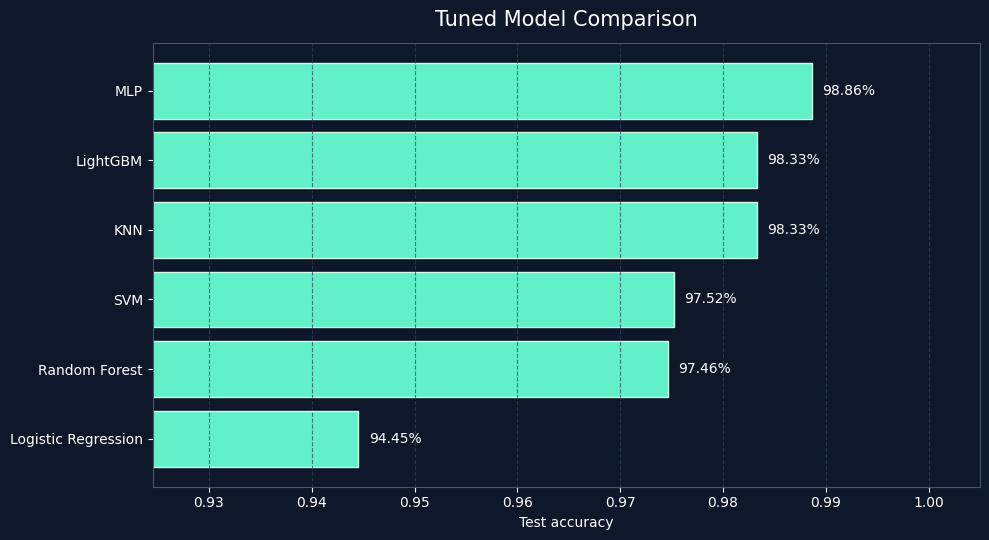

Saved: /content/drive/MyDrive/asl_project/report_figures/model_comparison.png


In [20]:
plot_df = results_df.sort_values('test_accuracy', ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

bars = ax.barh(plot_df['model'], plot_df['test_accuracy'], color='#62f0c8', edgecolor='#d1fae5', linewidth=1.0)
ax.set_xlim(max(0.90, plot_df['test_accuracy'].min() - 0.02), 1.005)
ax.set_xlabel('Test accuracy', color='white')
ax.set_title('Tuned Model Comparison', color='white', fontsize=15, pad=12)
ax.tick_params(colors='white')
ax.grid(axis='x', color='#334155', linestyle='--', alpha=0.7)

for bar in bars:
    value = bar.get_width()
    ax.text(value + 0.001, bar.get_y() + bar.get_height() / 2, f'{value:.2%}', va='center', color='white', fontsize=10)

for spine in ax.spines.values():
    spine.set_color('#475569')

plt.tight_layout()
model_plot_path = FIGURE_DIR / 'model_comparison.png'
plt.savefig(model_plot_path, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print(f'Saved: {model_plot_path}')


## 8. Final Model Metrics

The best model is selected by held-out test accuracy.


In [21]:
best_model_name = results_df.iloc[0]['model']
best_model = tuned_models[best_model_name]

print(f'Best model by test accuracy: {best_model_name}')
print(f'Test accuracy: {results_df.iloc[0]["test_accuracy"]:.4f}')
print(f'Best params: {results_df.iloc[0]["best_params"]}')

y_pred = best_model.predict(X_test)

report_dict = classification_report(
    y_test_enc,
    y_pred,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).T
report_df.to_csv(FIGURE_DIR / 'classification_report.csv')

final_metrics = pd.DataFrame([
    {'metric': 'Accuracy', 'score': accuracy_score(y_test_enc, y_pred)},
    {'metric': 'Macro Precision', 'score': report_dict['macro avg']['precision']},
    {'metric': 'Macro Recall', 'score': report_dict['macro avg']['recall']},
    {'metric': 'Macro F1', 'score': report_dict['macro avg']['f1-score']},
    {'metric': 'Weighted Precision', 'score': report_dict['weighted avg']['precision']},
    {'metric': 'Weighted Recall', 'score': report_dict['weighted avg']['recall']},
    {'metric': 'Weighted F1', 'score': report_dict['weighted avg']['f1-score']},
])

final_metrics.to_csv(FIGURE_DIR / 'final_model_metrics.csv', index=False)
display(final_metrics.style.format({'score': '{:.4f}'}))

print('\nClassification report:')
print(classification_report(y_test_enc, y_pred, target_names=le.classes_, zero_division=0))


Best model by test accuracy: MLP
Test accuracy: 0.9886
Best params: {"alpha": 0.0001, "hidden_layer_sizes": [512, 256], "learning_rate_init": 0.001}


,metric,score
0,Accuracy,0.9886
1,Macro Precision,0.9881
2,Macro Recall,0.9882
3,Macro F1,0.9881
4,Weighted Precision,0.9887
5,Weighted Recall,0.9886
6,Weighted F1,0.9886



Classification report:
              precision    recall  f1-score   support

           A       1.00      0.99      0.99       254
           B       1.00      1.00      1.00       261
           C       0.98      1.00      0.99       242
           D       0.99      0.99      0.99       272
      DELETE       0.99      0.99      0.99       228
           E       0.99      0.99      0.99       261
           F       1.00      0.99      0.99       302
           G       0.99      1.00      0.99       274
           H       0.99      1.00      1.00       267
           I       1.00      0.99      0.99       267
           K       0.99      0.99      0.99       289
           L       1.00      0.99      1.00       281
           M       0.96      0.97      0.97       218
           N       0.97      0.95      0.96       196
           O       0.97      0.98      0.98       258
           P       1.00      0.99      0.99       244
           Q       0.99      0.99      0.99       253
   

## 9. Confusion Matrix



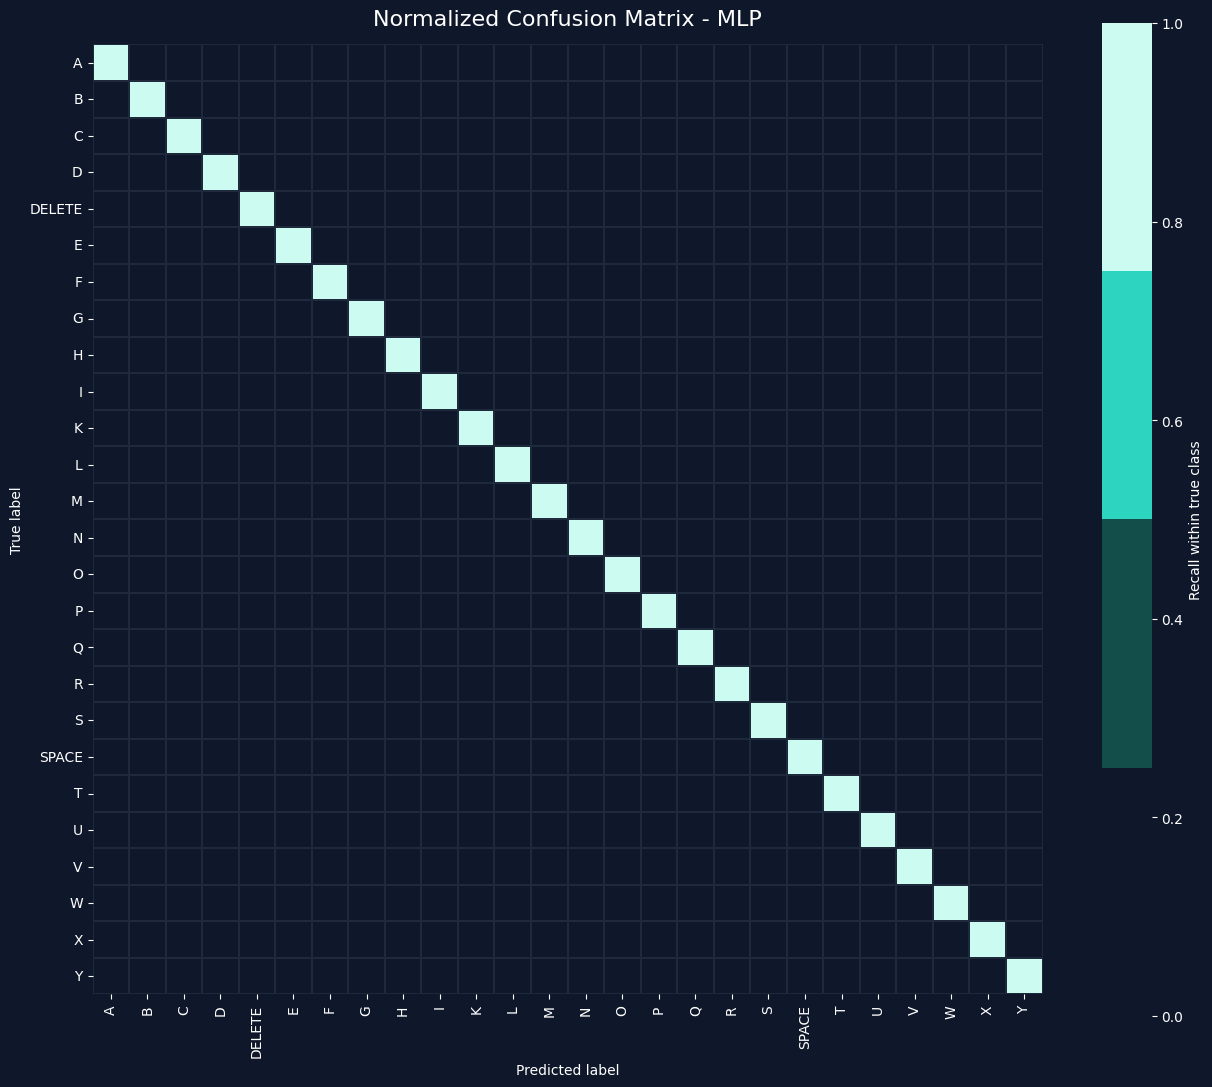

Saved: /content/drive/MyDrive/asl_project/report_figures/confusion_matrix_normalized.png


In [22]:
cm = confusion_matrix(y_test_enc, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
cm_df.to_csv(FIGURE_DIR / 'confusion_matrix_counts.csv')

cm_norm = cm.astype(np.float64) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
cm_norm_df = pd.DataFrame(cm_norm, index=le.classes_, columns=le.classes_)
cm_norm_df.to_csv(FIGURE_DIR / 'confusion_matrix_normalized.csv')

fig, ax = plt.subplots(figsize=(13, 11))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

sns.heatmap(
    cm_norm_df,
    cmap=sns.color_palette(['#0f172a', '#134e4a', '#2dd4bf', '#ccfbf1'], as_cmap=True),
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.25,
    linecolor='#1e293b',
    cbar_kws={'label': 'Recall within true class'},
    ax=ax,
)

ax.set_title(f'Normalized Confusion Matrix - {best_model_name}', color='white', fontsize=16, pad=14)
ax.set_xlabel('Predicted label', color='white')
ax.set_ylabel('True label', color='white')
ax.tick_params(axis='x', colors='white', rotation=90)
ax.tick_params(axis='y', colors='white', rotation=0)

colorbar = ax.collections[0].colorbar
colorbar.ax.yaxis.label.set_color('white')
colorbar.ax.tick_params(colors='white')

plt.tight_layout()
cm_plot_path = FIGURE_DIR / 'confusion_matrix_normalized.png'
plt.savefig(cm_plot_path, dpi=220, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print(f'Saved: {cm_plot_path}')


## 10. Per-Class F1 Scores and Error Pairs

This section helps explain model limitations. Low-F1 classes and high off-diagonal confusion pairs usually correspond to signs with similar hand geometry.


,precision,recall,f1-score,support
N,0.969,0.954,0.961,196
M,0.963,0.968,0.966,218
O,0.973,0.981,0.977,258
U,0.986,0.978,0.982,278
SPACE,0.981,0.986,0.983,211
X,0.973,1.000,0.986,254
T,0.992,0.981,0.987,265
D,0.989,0.985,0.987,272
R,0.982,0.993,0.988,281
Q,0.988,0.988,0.988,253


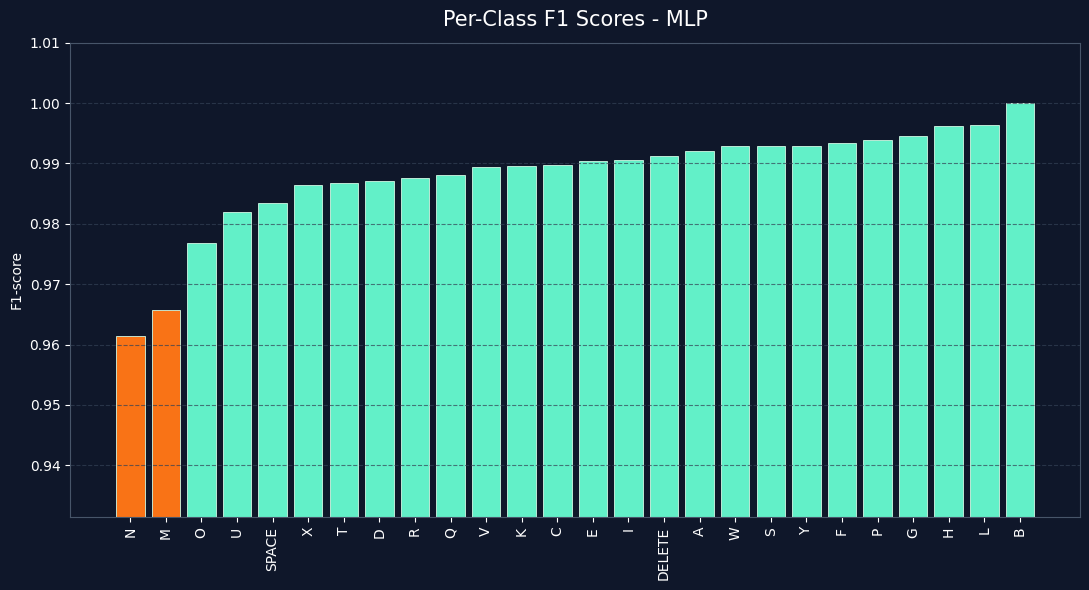

Saved: /content/drive/MyDrive/asl_project/report_figures/per_class_f1.png


,true_label,predicted_label,count,true_class_errors_percent
0,N,M,6,3.061224
1,M,N,4,1.834862
2,U,R,4,1.438849
3,S,X,3,1.067616
4,K,V,2,0.692042
5,I,O,2,0.749064
6,R,U,2,0.711744
7,P,Q,2,0.819672
8,D,O,2,0.735294
9,F,O,2,0.662252


In [23]:
per_class_df = report_df.loc[le.classes_, ['precision', 'recall', 'f1-score', 'support']].copy()
per_class_df = per_class_df.sort_values('f1-score', ascending=True)
per_class_df.to_csv(FIGURE_DIR / 'per_class_metrics.csv')

display(per_class_df.head(10).style.format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}',
}))

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

colors = ['#f97316' if score < 0.97 else '#62f0c8' for score in per_class_df['f1-score']]
ax.bar(per_class_df.index, per_class_df['f1-score'], color=colors, edgecolor='#d1fae5', linewidth=0.6)
ax.set_ylim(max(0.85, per_class_df['f1-score'].min() - 0.03), 1.01)
ax.set_ylabel('F1-score', color='white')
ax.set_title(f'Per-Class F1 Scores - {best_model_name}', color='white', fontsize=15, pad=12)
ax.tick_params(axis='x', colors='white', rotation=90)
ax.tick_params(axis='y', colors='white')
ax.grid(axis='y', color='#334155', linestyle='--', alpha=0.7)

for spine in ax.spines.values():
    spine.set_color('#475569')

plt.tight_layout()
f1_plot_path = FIGURE_DIR / 'per_class_f1.png'
plt.savefig(f1_plot_path, dpi=220, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print(f'Saved: {f1_plot_path}')

error_pairs = []
for true_idx, true_label in enumerate(le.classes_):
    for pred_idx, pred_label in enumerate(le.classes_):
        if true_idx == pred_idx:
            continue
        count = int(cm[true_idx, pred_idx])
        if count > 0:
            error_pairs.append({
                'true_label': true_label,
                'predicted_label': pred_label,
                'count': count,
                'true_class_errors_percent': 100 * count / max(cm[true_idx].sum(), 1),
            })

error_pairs_df = pd.DataFrame(error_pairs).sort_values('count', ascending=False).reset_index(drop=True)
error_pairs_df.to_csv(FIGURE_DIR / 'top_confusion_pairs.csv', index=False)

display(error_pairs_df.head(15))


## 11. Save Deployment Artifacts

The Streamlit app expects:

- `app/best_model.pkl`
- `app/label_encoder.pkl`

Most scikit-learn classifiers support `predict`, but the app uses `predict_proba` to show confidence. If the highest-accuracy model does not support probabilities, the notebook saves the best available probability model instead and prints a warning.


In [24]:
probability_models = [name for name, model in tuned_models.items() if hasattr(model, 'predict_proba')]

if hasattr(best_model, 'predict_proba'):
    deployment_model_name = best_model_name
    deployment_model = best_model
else:
    probability_results = results_df[results_df['model'].isin(probability_models)].copy()
    if probability_results.empty:
        raise RuntimeError('No tuned model supports predict_proba; cannot save app-compatible model.')
    deployment_model_name = probability_results.iloc[0]['model']
    deployment_model = tuned_models[deployment_model_name]
    print(
        f'Warning: {best_model_name} does not support predict_proba. '
        f'Saving {deployment_model_name} for the app instead.'
    )

if SAVE_DEPLOYMENT_ARTIFACTS:
    APP_DIR.mkdir(exist_ok=True)
    model_path = APP_DIR / 'best_model.pkl'
    encoder_path = APP_DIR / 'label_encoder.pkl'

    with open(model_path, 'wb') as f:
        pickle.dump(deployment_model, f)

    with open(encoder_path, 'wb') as f:
        pickle.dump(le, f)

    print(f'Saved deployment model: {model_path}')
    print(f'Saved label encoder:    {encoder_path}')
    print(f'Deployment model name:  {deployment_model_name}')
else:
    print('SAVE_DEPLOYMENT_ARTIFACTS is False. Model files were not written.')


Saved deployment model: /content/drive/MyDrive/asl_project/app/best_model.pkl
Saved label encoder:    /content/drive/MyDrive/asl_project/app/label_encoder.pkl
Deployment model name:  MLP
